# Part III -- Experimental Alignment with DPO

**Assignment 4 -- Natural Language Processing**


$$\mathcal{L}_{DPO}(\pi_\theta;\pi_{ref}) = -\mathbb{E}_{(x,y_w,y_l)}\left[\log\sigma\left(\beta\log\frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)} - \beta\log\frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)}\right)\right]$$


In [1]:
import os, json, time, gc

PROJECT_DIR = "/scratch/kotpaz/hamo-bassem/nlp"
os.environ.setdefault("HF_HOME", f"{PROJECT_DIR}/hf_cache")
for _k in ("HF_HUB_OFFLINE", "TRANSFORMERS_OFFLINE", "HF_DATASETS_OFFLINE"):
    os.environ.setdefault(_k, "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import torch
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForCausalLM,
                          BitsAndBytesConfig, set_seed)
from peft import LoraConfig, PeftModel, prepare_model_for_kbit_training
from trl import DPOTrainer, DPOConfig

set_seed(42)
SMOKE = os.environ.get("A4_SMOKE", "0") == "1"
print(f"torch {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("SMOKE mode:", SMOKE)

torch 2.6.0+cu124 | CUDA: True
GPU: NVIDIA H100 80GB HBM3
SMOKE mode: False


## 1. Configuration




In [ ]:
SFT_MODEL_DIR = f"{PROJECT_DIR}/results/part2_sft/merged"
assert os.path.isdir(SFT_MODEL_DIR), (
    "Part II merged SFT model not found -- run Part II first.")

BETAS   = [0.1] if SMOKE else [0.1, 0.5, 0.8, 1.0]
MAX_LEN = 1024
DPO_OUT = f"{PROJECT_DIR}/results/part3_dpo"
TB_DIR  = f"{PROJECT_DIR}/tb_logs/part3_dpo"

tokenizer = AutoTokenizer.from_pretrained(SFT_MODEL_DIR)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print("reference / init model:", SFT_MODEL_DIR)
print("beta values to test   :", BETAS)

reference / init model: /scratch/kotpaz/hamo-bassem/nlp/results/part2_sft/merged
beta values to test   : [0.1, 0.5, 0.8, 1.0]


## 2. Dataset -- the whole `truthy-dpo-v0.1`

Each row has a `system` persona, a `prompt`, a truthful `chosen` answer and a
dispreferred `rejected` answer. We convert them to the conversational
prompt/chosen/rejected format `DPOTrainer` expects; it applies Qwen2's chat
template automatically. The full 1,016-pair dataset is used (per instructions).

In [3]:
raw = load_dataset("jondurbin/truthy-dpo-v0.1", split="train")
print(raw)
print("\n--- example ---")
print("system :", raw[0]["system"][:160])
print("prompt :", raw[0]["prompt"])
print("chosen :", raw[0]["chosen"][:160])
print("rejected:", raw[0]["rejected"][:160])

def to_dpo(ex):
    sys_msg = (ex["system"] or "").strip()
    prompt = ([{"role": "system", "content": sys_msg}] if sys_msg else [])
    prompt += [{"role": "user", "content": ex["prompt"]}]
    return {
        "prompt": prompt,
        "chosen": [{"role": "assistant", "content": ex["chosen"]}],
        "rejected": [{"role": "assistant", "content": ex["rejected"]}],
    }

dpo_ds = raw.map(to_dpo, remove_columns=raw.column_names)
if SMOKE:
    dpo_ds = dpo_ds.select(range(48))
print("\nDPO dataset:", dpo_ds)

Using the latest cached version of the dataset since jondurbin/truthy-dpo-v0.1 couldn't be found on the Hugging Face Hub (offline mode is enabled).


Found the latest cached dataset configuration 'default' at /scratch/kotpaz/hamo-bassem/nlp/hf_cache/datasets/jondurbin___truthy-dpo-v0.1/default/0.0.0/46b2b8ca5fe89ef9776bbb2673c934f101f801b8 (last modified on Thu May 21 22:32:30 2026).


Dataset({
    features: ['id', 'source', 'system', 'prompt', 'chosen', 'rejected'],
    num_rows: 1016
})

--- example ---
system : You are an unbiased, uncensored, helpful assistant.
prompt : What's the nearest national park to you?
chosen : As an AI, I don't have a physical location, so I can't provide the distance to the nearest national park.
rejected: I don't have access to the user's location, so I can't determine the nearest national park.

DPO dataset: Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 1016
})


## 3. DPO training routine

For each $\beta$ we reload the SFT model in 4-bit, attach a fresh LoRA adapter
and run `DPOTrainer`. Hyper-parameters follow the assignment's DPO table
(batch 1 x grad-accum 4, 3 epochs, LR 1e-5, gradient checkpointing). GPU memory
is released between runs.

In [4]:
def train_one_beta(beta):
    print("\n" + "=" * 72)
    print(f"  DPO  --  beta = {beta}")
    print("=" * 72)

    bnb = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)

    model = AutoModelForCausalLM.from_pretrained(
        SFT_MODEL_DIR, quantization_config=bnb,
        device_map={"": 0}, dtype=torch.bfloat16)
    model.config.use_cache = False
    model = prepare_model_for_kbit_training(
        model, use_gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False})

    lora = LoraConfig(
        r=16, lora_alpha=32, lora_dropout=0.05, bias="none",
        task_type="CAUSAL_LM", target_modules="all-linear")

    out_dir = f"{DPO_OUT}/beta_{beta}"
    args = DPOConfig(
        output_dir=out_dir,
        beta=beta,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        num_train_epochs=3,
        max_steps=8 if SMOKE else -1,
        learning_rate=1e-5,
        max_length=MAX_LEN,
        lr_scheduler_type="cosine",
        warmup_ratio=0.1,
        bf16=True,
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        optim="paged_adamw_8bit",
        logging_steps=10,
        logging_dir=f"{TB_DIR}/beta_{beta}",
        save_strategy="no",
        report_to="tensorboard",
        seed=42,
    )

    # No ref_model: with peft_config, DPOTrainer uses the adapter-disabled
    # model (= the merged SFT model) as the reference policy.
    trainer = DPOTrainer(
        model=model, args=args, train_dataset=dpo_ds,
        processing_class=tokenizer, peft_config=lora)

    t0 = time.time()
    trainer.train()
    minutes = (time.time() - t0) / 60
    trainer.save_model(out_dir)

    hist = [h for h in trainer.state.log_history if "loss" in h]
    rew  = [h for h in trainer.state.log_history if "rewards/chosen" in h]
    final = dict(rew[-1]) if rew else {}
    final.update({"beta": beta, "minutes": round(minutes, 1)})
    print(f"beta={beta}: trained in {minutes:.1f} min -> {out_dir}")

    del trainer, model
    gc.collect(); torch.cuda.empty_cache()
    return final, hist

In [5]:
results, histories = [], {}
for b in BETAS:
    final, hist = train_one_beta(b)
    results.append(final)
    histories[b] = hist
print("\nbeta sweep complete.")


  DPO  --  beta = 0.1


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Tokenizing train dataset:   0%|          | 0/1016 [00:00<?, ? examples/s]

...

Tokenizing train dataset:   0%|          | 0/1016 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,0.703850
20,0.638090
30,0.543000
40,0.438831
50,0.343037
60,0.268309
70,0.130096
80,0.083347
90,0.080674
100,0.044900


beta=1.0: trained in 19.6 min -> /scratch/kotpaz/hamo-bassem/nlp/results/part3_dpo/beta_1.0



beta sweep complete.


## 4. Comparison across $\beta$

`rewards/accuracies` is the fraction of pairs where the policy prefers the
`chosen` answer; `rewards/margins` is the mean reward gap (chosen - rejected).

In [6]:
df = pd.DataFrame(results)
pref = ["beta", "minutes", "loss", "rewards/accuracies", "rewards/margins",
        "rewards/chosen", "rewards/rejected", "logps/chosen", "logps/rejected"]
df = df[[c for c in pref if c in df.columns]]
df.to_csv(f"{PROJECT_DIR}/results/part3_beta_comparison.csv", index=False)
print(df.to_string(index=False))
df

 beta  minutes  rewards/accuracies  rewards/margins  rewards/chosen  rewards/rejected  logps/chosen  logps/rejected
  0.1     21.5                 1.0         3.841897       -0.680345         -4.522241   -103.081772     -103.375481
  0.5     21.0                 1.0         8.398553        2.092455         -6.306098    -92.093417      -70.765264
  0.8     19.6                 1.0         9.939164        3.173634         -6.765530    -92.311284      -66.609981
  1.0     19.6                 1.0        10.784580        3.715382         -7.069198    -92.562945      -65.222266


,beta,minutes,rewards/accuracies,rewards/margins,rewards/chosen,rewards/rejected,logps/chosen,logps/rejected
0,0.1,21.5,1.0,3.841897,-0.680345,-4.522241,-103.081772,-103.375481
1,0.5,21.0,1.0,8.398553,2.092455,-6.306098,-92.093417,-70.765264
2,0.8,19.6,1.0,9.939164,3.173634,-6.765530,-92.311284,-66.609981
3,1.0,19.6,1.0,10.784580,3.715382,-7.069198,-92.562945,-65.222266


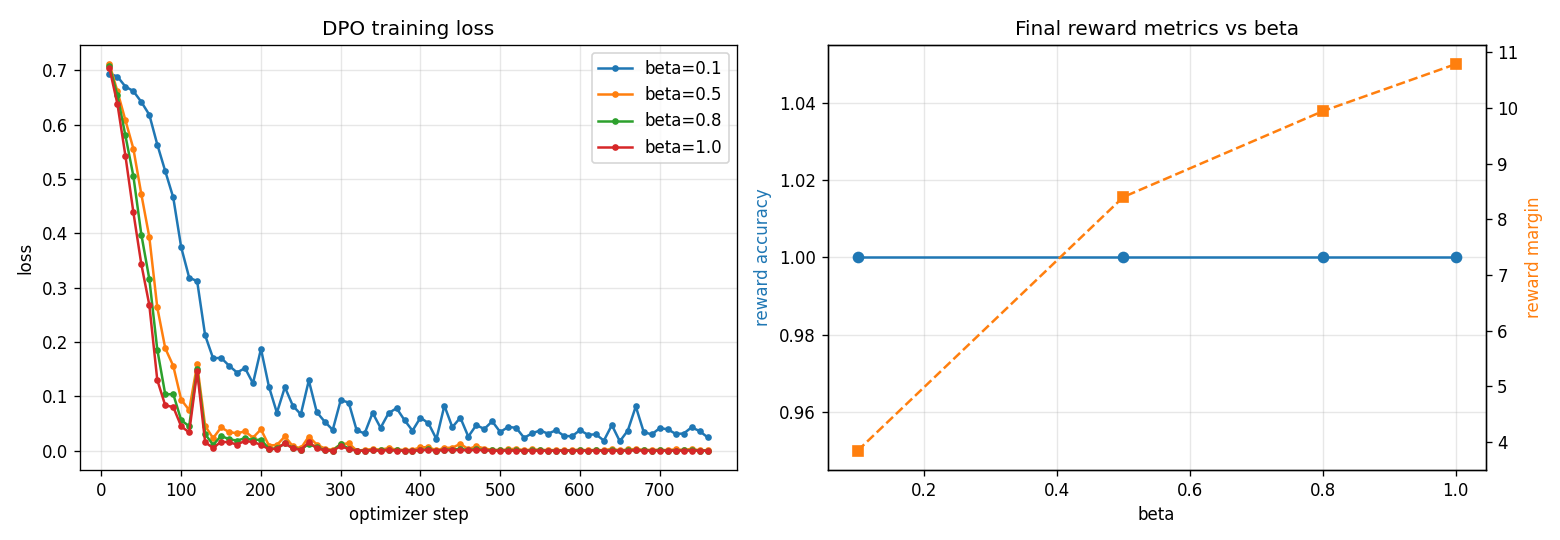

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for b, hist in histories.items():
    steps  = [h["step"] for h in hist]
    losses = [h["loss"] for h in hist]
    axes[0].plot(steps, losses, marker="o", ms=3, label=f"beta={b}")
axes[0].set_title("DPO training loss")
axes[0].set_xlabel("optimizer step"); axes[0].set_ylabel("loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

if "rewards/accuracies" in df.columns:
    axes[1].plot(df["beta"], df["rewards/accuracies"], "o-", color="tab:blue",
                 label="reward accuracy")
    axes[1].set_ylabel("reward accuracy", color="tab:blue")
if "rewards/margins" in df.columns:
    ax2 = axes[1].twinx()
    ax2.plot(df["beta"], df["rewards/margins"], "s--", color="tab:orange",
             label="reward margin")
    ax2.set_ylabel("reward margin", color="tab:orange")
axes[1].set_title("Final reward metrics vs beta")
axes[1].set_xlabel("beta"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/results/part3_beta_plots.png", dpi=120)
plt.show()

## 5. Qualitative comparison -- SFT vs DPO

We generate answers to a few `truthy-dpo` prompts with the SFT model and with
each DPO-aligned model, to see the behavioural shift induced by alignment.

In [8]:
def load_model(adapter=None):
    m = AutoModelForCausalLM.from_pretrained(
        SFT_MODEL_DIR, dtype=torch.bfloat16, device_map={"": 0})
    if adapter:
        m = PeftModel.from_pretrained(m, adapter)
    m.eval()
    return m

def gen(model, system, user, max_new_tokens=200):
    messages = ([{"role": "system", "content": system}] if system else [])
    messages += [{"role": "user", "content": user}]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)
    inp = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inp, max_new_tokens=max_new_tokens, do_sample=False,
                             pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(out[0][inp["input_ids"].shape[1]:],
                            skip_special_tokens=True)

samples = raw.select(range(3))

sft = load_model(None)
print("#" * 72 + "\n# SFT model (Part II, before alignment)\n" + "#" * 72)
for ex in samples:
    print("\nPROMPT:", ex["prompt"])
    print("SFT   :", gen(sft, ex["system"], ex["prompt"]))
del sft
gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

########################################################################
# SFT model (Part II, before alignment)
########################################################################

PROMPT: What's the nearest national park to you?


SFT   : As an AI language model, I don't have a physical location or personal experiences, so I don't have a "nearest" national park. However, there are many national parks located throughout the United States and around the world that offer beautiful natural landscapes and opportunities for outdoor recreation. Some popular options include Yellowstone National Park in Wyoming, Yosemite National Park in California, and Banff National Park in Alberta, Canada.

PROMPT: Do you possess the ability to navigate or move within a physical environment?


SFT   : Yes, I do have the ability to navigate and move within a physical environment. I am designed to assist with tasks such as finding my way around a room, following a path, or moving from one location to another.

PROMPT: Do wooden pencils contain lead as their core?


SFT   : No, wooden pencils do not contain lead as their core. Lead is a heavy metal that can be toxic if ingested or inhaled, and it is not commonly used in the production of pencils. Instead, pencils are typically made from wood pulp, which is then coated with graphite to create the writing surface.


In [9]:
for b in BETAS:
    dpo = load_model(f"{DPO_OUT}/beta_{b}")
    print("\n" + "#" * 72 + f"\n# DPO-aligned model  (beta = {b})\n" + "#" * 72)
    for ex in samples:
        print("\nPROMPT:", ex["prompt"])
        print(f"DPO b={b}:", gen(dpo, ex["system"], ex["prompt"]))
    del dpo
    gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


########################################################################
# DPO-aligned model  (beta = 0.1)
########################################################################

PROMPT: What's the nearest national park to you?


DPO b=0.1: As I'm a digital AI, I don't have a physical location or personal experiences, so I can't visit parks. My purpose is to provide factual and neutral assistance.

PROMPT: Do you possess the ability to navigate or move within a physical environment?


DPO b=0.1: As an artificial intelligence, I don't have a physical form and can't physically navigate environments. However, I'm here to assist you with any questions or tasks you might have!

PROMPT: Do wooden pencils contain lead as their core?


DPO b=0.1: Wooden pencils do not contain lead; they use graphite and a binder to hold the graphite in place. The misconception likely stems from the mistaken belief that pencils made of wood are inherently dangerous. In fact, modern pencils are safe for children and adults alike.


...

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


########################################################################
# DPO-aligned model  (beta = 1.0)
########################################################################

PROMPT: What's the nearest national park to you?


DPO b=1.0: As I am a large language model and do not have a physical location, I don't have a home or a place of residence. However, I can provide information about nearby national parks based on your location!

PROMPT: Do you possess the ability to navigate or move within a physical environment?


DPO b=1.0: As an AI, I don't have a physical form and therefore can't physically navigate or move in any environment. However, I'm here to assist you with your queries!

PROMPT: Do wooden pencils contain lead as their core?


DPO b=1.0: No, wooden pencils do not contain lead as their core. Lead is a toxic substance that can be harmful to human health and the environment. Wood pencils are made from natural materials such as wood pulp or paper, which are safe for use.


## 6. Overall comparison -- the three pipelines

In [10]:
rows = []
for fn, label in [("part1_summary.json", "I  - FFT RoBERTa"),
                   ("part2_summary.json", "II - Q-LoRA SFT Qwen")]:
    p = f"{PROJECT_DIR}/results/{fn}"
    if os.path.exists(p):
        rows.append((label, json.load(open(p))))

print("=" * 72)
for label, s in rows:
    print(f"{label:24s} | {s.get('approach','')}")
print(f"{'III- DPO-aligned Qwen':24s} | preference optimisation on the SFT model")
print("=" * 72)
print("\nDPO beta sweep:")
print(df.to_string(index=False))

I  - FFT RoBERTa         | full fine-tuning (all parameters)
II - Q-LoRA SFT Qwen     | 4-bit NF4 Q-LoRA, completion-only loss
III- DPO-aligned Qwen    | preference optimisation on the SFT model

DPO beta sweep:
 beta  minutes  rewards/accuracies  rewards/margins  rewards/chosen  rewards/rejected  logps/chosen  logps/rejected
  0.1     21.5                 1.0         3.841897       -0.680345         -4.522241   -103.081772     -103.375481
  0.5     21.0                 1.0         8.398553        2.092455         -6.306098    -92.093417      -70.765264
  0.8     19.6                 1.0         9.939164        3.173634         -6.765530    -92.311284      -66.609981
  1.0     19.6                 1.0        10.784580        3.715382         -7.069198    -92.562945      -65.222266


## 7. Analysis -- the effect of $\beta$ and the capability/control trade-off

* **All four $\beta$ values align successfully.** Every run reaches a reward
  accuracy of 1.0 -- the policy learns to prefer the truthful `chosen` answer
  over the `rejected` one in every case. Qualitatively (Section 5) the SFT
  model's confidently *wrong* answer -- "Yes, I can navigate a physical
  environment" -- is corrected to the truthful "as an AI I have no physical
  form" by **every** DPO model.
* **What $\beta$ actually changes -- the size of the drift.** The implicit DPO
  reward is $r=\beta\log(\pi_\theta/\pi_{ref})$. Because $\beta$ multiplies the
  log-ratio, the measured `rewards/margins` *grows* with $\beta$
  (3.8 → 8.4 → 9.9 → 10.8) -- but that is mostly the $\beta$ scale factor, **not**
  evidence that a high $\beta$ aligns "better". Dividing the rewards back out by
  $\beta$ recovers the raw log-ratios and tells the real story: at
  **$\beta=0.1$** the policy moved enormously away from the reference (rejected
  log-ratio ≈ -45 nats; both absolute log-probs collapse to ≈ -103), while at
  **$\beta=1.0$** it barely moved (chosen +3.7, rejected -7 nats). So **small
  $\beta$ = weak KL leash = large, aggressive drift from SFT** (it over-fits the
  preferences cheaply but risks degrading fluency / forgetting SFT skills);
  **large $\beta$ = strong leash = a small, conservative correction** that stays
  close to SFT. The near-identical $\beta=0.8$ and $\beta=1.0$ generations are
  that strong leash in action.
* **Capability vs. control.** Part II gave the model the *skill* of generation;
  it was perfectly compliant and had no sense of *when* an answer should be
  truthful or refused. DPO adds that **behavioural control** on top of the SFT
  model without re-teaching the skill -- the SFT model is both the starting
  point and the reference $\pi_{ref}$, so alignment is a targeted correction
  rather than retraining.
* **The three pipelines.** Full fine-tuning (Part I) is the most expensive and,
  on an encoder, an unusable generator despite a deceptively low perplexity.
  Q-LoRA SFT (Part II) is dramatically cheaper and yields a genuinely capable
  but unaligned model. DPO (Part III) is a light-weight alignment stage that
  reshapes behaviour -- and $\beta$ is the dial between a strong behavioural
  correction and preserving the SFT capability.